In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
import random
from sched import scheduler

import torch
import torch.nn as nn
import torch.nn.functional as F
import gpytorch
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Base GP model
class GP(gpytorch.models.ExactGP):
    def __init__(self, x_train, y_train):
        super().__init__(x_train, y_train, gpytorch.likelihoods.GaussianLikelihood())
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        function_mean = self.mean_module(x)
        function_covar = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(function_mean, function_covar)

# Sampling function
def f(x):
    gp = GP(x, torch.randn(len(x)))
    gp.covar_module.outputscale = 1.0
    gp.covar_module.base_kernel.lengthscale = 0.5
    gp.likelihood.noise = 0.2
    with torch.no_grad():
        targets_dist = gp.likelihood(gp(x))
    return targets_dist.rsample(), gp

# sin function
def h(x, scale=3.0):
    return torch.sin(x/scale) + 2.0

# Build input data, initialize the GP, and sample from it
random.seed(63)
np.random.seed(63)
torch.manual_seed(63)

x = torch.linspace(-5, 5, 500)
y, gp = f(x)
y_shift = y + h(x, scale=3.0)

train_mask = (x > -3) & (x < 3)
to_false = torch.randperm(len(x))[:(train_mask.sum() * 0.5).int()]
train_mask[to_false] = False

x_train = x[train_mask].reshape(-1, 1)
y_train = y[train_mask]
x_test = x[~train_mask].reshape(-1, 1)
y_test = y[~train_mask]

print(f'x_train.shape = {x_train.shape},\ny_train.shape = {y_train.shape},\nx_test.shape = {x_test.shape},\ny_test.shape = {y_test.shape}')

x_train.shape = torch.Size([213, 1]),
y_train.shape = torch.Size([213]),
x_test.shape = torch.Size([287, 1]),
y_test.shape = torch.Size([287])


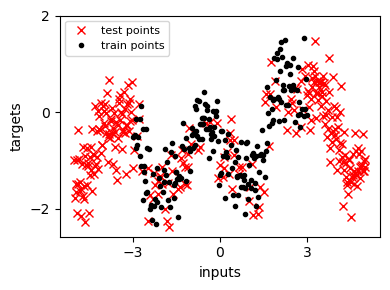

In [6]:
fig, ax = plt.subplots(figsize=[4, 3])
ax.plot(x_test, y_test, 'x', color='r', label='test points')
ax.plot(x_train, y_train, '.', color='k', label='train points')
ax.set_xlabel('inputs')
ax.set_ylabel('targets')
ax.set_xticks([-3, 0, 3])
ax.set_yticks([-2, 0, 2])
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
# fig.savefig('./plots/1D_data_pretrain.pdf', dpi=300, bbox_inches='tight')  # save fig

In [7]:
def plot_confidence_region(y_data, y_mean, y_lower, y_upper, fig_path=None):
    fig, ax = plt.subplots(figsize=[4, 3])
    ax.plot(x_train, y_data, '.', color='k', label='training points')
    ax.plot(x_test, y_mean, color='r', linewidth=1, label='posterior mean')
    ax.fill_between(x_test.squeeze(), y_lower, y_upper, color='r', alpha=0.12)
    ax.set_xticks([])
    ax.set_yticks([-2.5, 0, 2.5])
    ax.set_xlabel('$x$')
    # ax.set_ylabel('$y$')
    ax.set_title('Mean posterior with 95% confidence', size=10, style='italic')
    ax.legend(fontsize=8)
    fig.tight_layout()
    # save figure as pdf
    if fig_path is not None:
        fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()

In [19]:
# cpu or cuda or mps
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [20]:
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [10]:
def train_gpr(model, criterion, optimizer, epochs=200, device="cpu"):
    model = model.to(device)
    x_train_ = x_train.to(device)
    y_train_ = y_train.to(device)
    losses = []
    for epoch in range(epochs):
        model.train()
        # Zero backprop gradients
        optimizer.zero_grad()
        # Get output from model
        output = model(x_train_)
        # Calc loss and backprop derivatives
        loss = - criterion(output, y_train_)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        if epoch % 100 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item()}')

    return losses

def evaluate_gpr(model, x, likelihood, device="cpu"):
    model = model.to(device)
    x_ = x.to(device)

    model.eval()
    likelihood.eval()

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        observed_pred = likelihood(model(x_))

    mean = observed_pred.mean.cpu().numpy()
    lower, upper = observed_pred.confidence_region()

    return mean, lower.cpu().numpy(), upper.cpu().numpy()

Epoch [0/500], Loss: 0.9529625773429871
Epoch [100/500], Loss: 0.927879810333252
Epoch [200/500], Loss: 0.9036049842834473
Epoch [300/500], Loss: 0.8801974654197693
Epoch [400/500], Loss: 0.8577350974082947


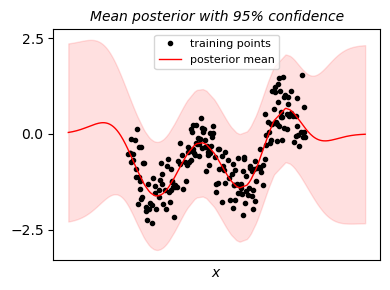

In [11]:
# initialize likelihood and model
gp_likelihood = gpytorch.likelihoods.GaussianLikelihood()
gp_model = ExactGPModel(x_train, y_train, gp_likelihood)

gp_optimizer = torch.optim.Adam(gp_model.parameters(), lr=0.001)
gp_criterion = gpytorch.mlls.ExactMarginalLogLikelihood(gp_likelihood, gp_model)

gp_losses = train_gpr(gp_model, gp_criterion, gp_optimizer, epochs=500, device=device)
gp_mean, gp_lower, gp_upper = evaluate_gpr(gp_model, x_test, gp_likelihood, device=device)
plot_confidence_region(y_train, gp_mean, gp_lower, gp_upper)

In [12]:
# Train BNN
def train_bnn(model, criterion, optimizer, num_mc=1, epochs=2000, device="cpu"):
    model = model.to(device)
    x_train_ = x_train.to(device)
    y_train_ = y_train.to(device)

    losses = []
    # bnn_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output_ = []
        kl_ = []
        for mc_run in range(num_mc):
            output, kl = model(x_train_, return_kl=True)
            output_.append(output)
            kl_.append(kl)
        output = torch.mean(torch.stack(output_), dim=0)
        kl = torch.mean(torch.stack(kl_), dim=0)
        loss = criterion(output, y_train_.view(-1,1)) + kl / len(x_train)

        loss.backward()
        optimizer.step()
        # bnn_scheduler.step()

        losses.append(loss.item())
        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item()}')

    return losses

def evaluate_bnn(model, num_mc=1000, device="cpu"):
    model = model.to(device)
    x_test_ = x_test.to(device)

    model.eval()
    with torch.no_grad():
        predicts = []
        for mc_run in range(num_mc):
            output = model(x_test_, return_kl=False)
            predicts.append(output.cpu().data.numpy())

        pred_mean = np.mean(predicts, axis=0)
        pred_std = np.std(predicts, axis=0)
        lower = pred_mean - 2 * pred_std
        upper = pred_mean + 2 * pred_std

    return pred_mean, lower.squeeze(), upper.squeeze()

In [ ]:
from csgp.models.dgp import DeepCSGP, DeepCompactGP
csgp_model = DeepCSGP(
    in_features=1,
    out_features=1,
    hidden_features=[10, 10],
    dyadic_levels=[6, 6, 6],
    anchor=False,
)

csgp_losses = train_bnn(
    model=csgp_model,
    criterion=nn.MSELoss(),
    optimizer=torch.optim.AdamW(csgp_model.parameters(), lr=0.001, weight_decay=0.0001),
    num_mc=10,
    epochs=2000,
    device=device,
)

Epoch [0/2000], Loss: 1.127265214920044
Epoch [200/2000], Loss: 0.2410714328289032
Epoch [400/2000], Loss: 0.23486295342445374
Epoch [600/2000], Loss: 0.2289438247680664
Epoch [800/2000], Loss: 0.2150924652814865
Epoch [1000/2000], Loss: 0.2156229317188263
Epoch [1200/2000], Loss: 0.20732825994491577
Epoch [1400/2000], Loss: 0.19635507464408875
Epoch [1600/2000], Loss: 0.20837938785552979
Epoch [1800/2000], Loss: 0.1885490119457245


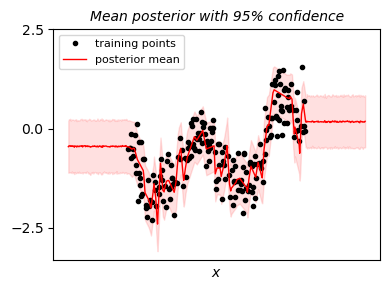

In [22]:
csgp_mean, csgp_lower, csgp_upper = evaluate_bnn(csgp_model, num_mc=1000)
plot_confidence_region(y_train, csgp_mean, csgp_lower, csgp_upper, fig_path='./plots/1D_csgp_mc10.pdf')

In [6]:
# Train DKL
def train_dkl(model, criterion, optimizer, num_mc=1, epochs=2000, device="cpu"):
    model = model.to(device)
    x_train_ = x_train.to(device)
    y_train_ = y_train.to(device)

    losses = []
    # bnn_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output_, kl = model.forward_with_MC(x_train_, num_mc=num_mc, return_kl=True)
        output = torch.mean(output_, dim=0)
        loss = criterion(output, y_train_.view(-1,1)) + kl / len(x_train)

        loss.backward()
        optimizer.step()
        # bnn_scheduler.step()

        losses.append(loss.item())
        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item()}')

    return losses

def evaluate_dkl(model, num_mc=1000, device="cpu"):
    model = model.to(device)
    x_test_ = x_test.to(device)

    model.eval()
    with torch.no_grad():
        
        predicts = model.forward_with_MC(x_test_, num_mc=num_mc, return_kl=False)
        predicts = predicts.cpu().data.numpy()
        # predicts = []
        # for mc_run in range(num_mc):
        #     output = model(x_test_, return_kl=False)
        #     predicts.append(output.cpu().data.numpy())

        pred_mean = np.mean(predicts, axis=0)
        pred_std = np.std(predicts, axis=0)
        lower = pred_mean - 2 * pred_std
        upper = pred_mean + 2 * pred_std

    return pred_mean, lower.squeeze(), upper.squeeze()

In [ ]:
from csgp.layers.gps import CSGP, CholesGP, CompactGPwEmbeding

class FeatureExtractor(nn.Module):
    def __init__(self, in_features, num_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 100)
        self.fc2 = nn.Linear(100, 50)
        self.fc3 = nn.Linear(50, num_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

class DKL(nn.Module):
    def __init__(self, input_dim, output_dim, dyadic_level=3):
        super(DKL, self).__init__()

        self.feature_extractor = FeatureExtractor(input_dim, 10)
        self.gp = CompactGPwEmbeding(
            in_features=10,
            out_features=output_dim,
            dyadic_level=dyadic_level,
            anchor=False,
        )
        
    def forward(self, x, return_kl=True):
        x = self.feature_extractor(x)
        res, kl = self.gp(x, return_kl=True)
        if return_kl:
            return res, kl
        else:
            return res
        
    def forward_with_MC(self, x, num_mc=1, return_kl=True):
        x = self.feature_extractor(x)
        res, kl = self.gp.mc_forward(x, num_mc=num_mc, return_kl=True)
        if return_kl:
            return res, kl
        else:
            return res

In [8]:
dkl_model = DKL(input_dim=1,
                output_dim=1,
                dyadic_level=10,
                )

dkl_losses = train_dkl(
    model=dkl_model,
    criterion=nn.MSELoss(),
    optimizer=torch.optim.Adam(dkl_model.parameters(), lr=0.001, weight_decay=0.0001),
    num_mc=10,
    epochs=1400
)

Epoch [0/1400], Loss: 2.2480592727661133
Epoch [200/1400], Loss: 0.44674861431121826
Epoch [400/1400], Loss: 0.2821178138256073
Epoch [600/1400], Loss: 0.29326242208480835
Epoch [800/1400], Loss: 0.24914002418518066
Epoch [1000/1400], Loss: 0.24771736562252045
Epoch [1200/1400], Loss: 0.2536062002182007


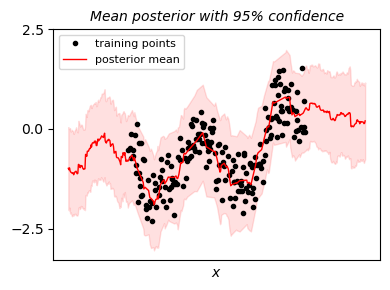

In [9]:
dkl_mean, dkl_lower, dkl_upper = evaluate_dkl(dkl_model, num_mc=5000)
plot_confidence_region(y_train, dkl_mean, dkl_lower, dkl_upper, fig_path='./logs/1D_dkl_mc20.pdf')

In [16]:
x = torch.ones(2, 1, 3)
x = x.unsqueeze(-3).expand(*x.shape[:-2], 10, -1, -1)
print(x.shape)

torch.Size([2, 10, 1, 3])
